# Example to calibrate the geometry of a TEXES observation (mapping mode)

In this example, we show how to use texespy to calibrate the geometry of a TEXES observation of Venus, when one of the hemispheres was mapped. The files used here are FITS files provided by Tommy Greathouse.

In [1]:
import texespy as texes
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys,os,glob
curr = os.getcwd()

## 1. Reading the FITS files

The files here are expected to follow the naming convention given by CAMPAIGN.RUN.OBSERVATION.red.fits

#### Defining the file names to be processed

In [2]:
dirfits = curr+'/'   #Path where the FITS files are stored (here in this example)

campaigns = [] ; runs = [] ; observations = [] ; force_slit_pas = []

campaign = "TX25B0922"
run = "1535"  #CO2 isotopes
observation = ["01","02","03","04"]  
force_slit_pa = None

#Concatenating the observations
for i in range(len(observation)):
    campaigns.append(campaign)
    runs.append(run)
    observations.append(observation[i])
    force_slit_pas.append(force_slit_pa)

#Defining the filenames
fitsnames = [""]*len(observations)
obsnames = [""]*len(observations)
for i in range(len(observations)):
    fitsnames[i] = campaigns[i]+"."+runs[i]+"."+observations[i]+".red.fits"
    obsnames[i] = runs[i]+"."+observations[i]

#### Reading the FITS files and calculating the geometry of the observations with SPICE

SPICE PARAMETERS
****************************************************************************************
Date of observation =  2025-09-22
Time of observation =  17:40:48.400
Sun-planet distance =  0.7186027290243839 AU
Earth-planet distance =  1.4688476740096073 AU
Planet angular size =  11.361548415684442 arcsec
Sub-observer latitude =  -0.3661812923986356 degrees     Sub-observer longitude =  50.11917778680626 degrees
Sub-solar latitude =  -2.238345410032928 degrees     Sub-solar longitude =  12.289005691847025 degrees
Doppler velocity between Earth and planet ::  8.070639055151691 km s-1
Phase angle ::  37.844492544950626 deg
Right ascension ::  155.8670966304331 degrees     Declination ::  11.176625258829123 deg
Right ascension of North Pole ::  155.86821032856787 degrees     Declination of North Pole ::  11.179586092884568 deg
Position angle ::  20.25455611288001 deg
Emission angle of observer on Earth ::  43.85678895346409 deg

TEXES PARAMETERS
*********************************

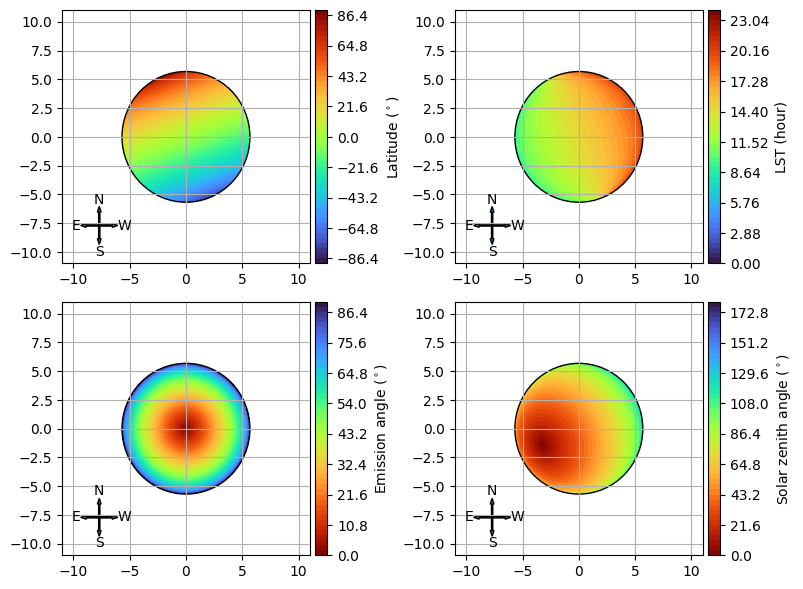

In [3]:
#Processing first file to get array sizes
geometry,x_vals,y_vals,waven,data,sky,error,trans_est_order,res_power = texes.calibrate.process_file(dirfits+fitsnames[0],MakePlot=True,force_slit_pa=force_slit_pas[0])

nscans = data.shape[0]
npixslit = data.shape[1]
nwave = data.shape[2]
norders = data.shape[3]
nimg = len(fitsnames)

#Processing all the files with no offsets
x_vals = np.zeros((nscans,npixslit,nimg))
y_vals = np.zeros((nscans,npixslit,nimg))
spectra = np.zeros((nscans,npixslit,nwave,norders,nimg))
sky = np.zeros((npixslit,nwave,norders,nimg))
error = np.zeros((npixslit,nwave,norders,nimg))
trans_est = np.zeros((nwave,norders,nimg))

ix = 0
for fitsname in fitsnames:

    geometry,x_vals[:,:,ix],y_vals[:,:,ix],waven,spectra[:,:,:,:,ix],sky[:,:,:,ix],error[:,:,:,ix],trans_est[:,:,ix],res_power = texes.calibrate.process_file(dirfits+fitsname,x_ini_offset=0.0,y_ini_offset=0.0,MakePlot=False,force_slit_pa=force_slit_pas[ix])
    
    ix += 1

## 2. Creating image for calibration

Now, to calibrate the geometry of the observations, we first need to create a spatial image of the TEXES measurements. Here, we take some wavelengths on the continuum to just reflect the brightness of the disk.

In [4]:
iorder = 0                            #Diffraction order to use
wavemin = 905.1 ; wavemax = 905.4     #Wavelength window to use

#Creating the image
icont = np.where( (waven[:,iorder]>=wavemin) & (waven[:,iorder]<=wavemax) )[0]

image_continuum = np.mean(spectra[:,:,icont,iorder,:],axis=2)  #(nscans,nslitpix,nimg)
waven_continuum = np.mean(waven[icont,iorder])                 #float
trans_continuum = np.mean(trans_est[icont,iorder,:],axis=0)    #(nimg)
sky_continuum = np.mean(sky[:,icont,iorder,:],axis=1)          #(nslitpix,nimg)

max_continuum = np.zeros(nimg)
for i in range(nimg):
    max_continuum[i] = np.max(image_continuum[:,:,i])

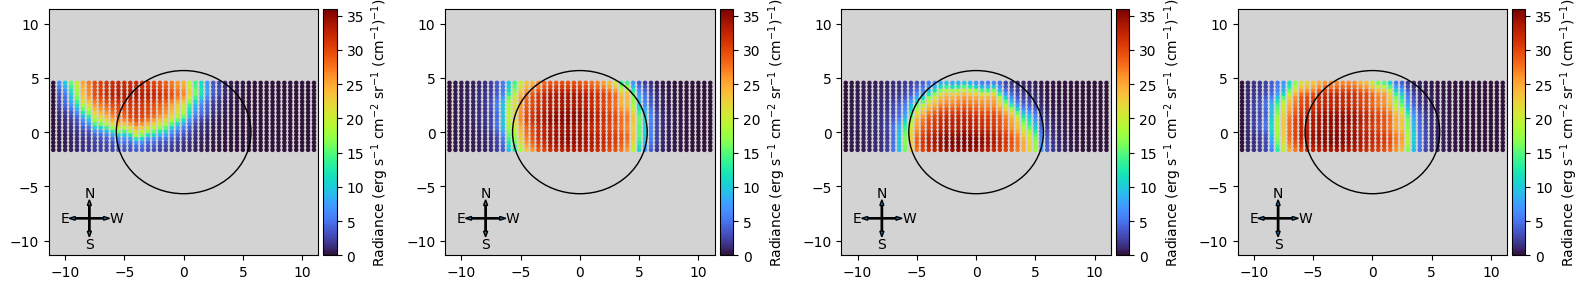

In [5]:
#Plotting images
fig,ax = plt.subplots(1,nimg,figsize=(4*nimg,3))

psize = 5.
vmin = 0. ; vmax = image_continuum.max()
angsize = geometry['angsize']
cmap = 'turbo'

ix = 0
for i in range(nimg):

    if nimg>1:
        axl = ax[i]
    else:
        axl = ax
        
    im = axl.scatter(x_vals[:,:,ix],y_vals[:,:,ix],c=image_continuum[:,:,ix],s=psize,vmin=vmin,vmax=vmax,cmap=cmap)
    Drawing_uncolored_circle = plt.Circle( (0.0, 0.0), angsize/2. ,fill = False, color='black')
    axl.add_artist( Drawing_uncolored_circle )
    texes.geometry.add_compass(axl)
    axl.set_xlim(-angsize,angsize)
    axl.set_ylim(-angsize,angsize)
    axl.set_facecolor('lightgray')

    # create an axes on the right side of ax. The width of cax will be 5%
    # of ax and the padding between cax and ax will be fixed at 0.05 inch.
    divider = make_axes_locatable(axl)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Radiance (erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)')
        
    ix += 1

plt.tight_layout()

## 3. Calibrating the geometry of each TEXES map

Now that we have created the images, we can proceed to the calibration. 

x_ini_off =  [4.1 0.7 0.8 2.6]
y_ini_off =  [-5.60000000e+00 -8.00000000e-01  1.60000000e+00 -2.48689958e-14]


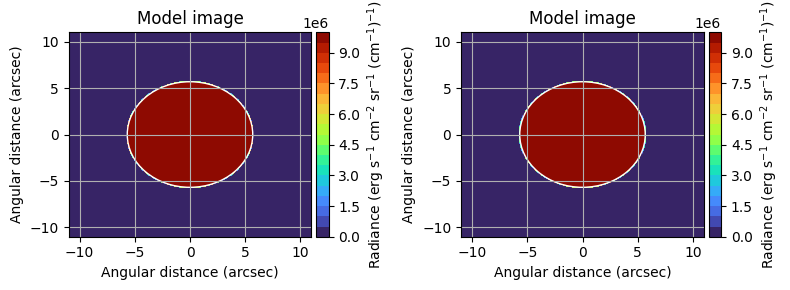

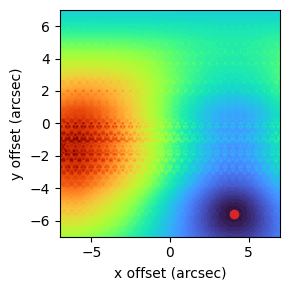

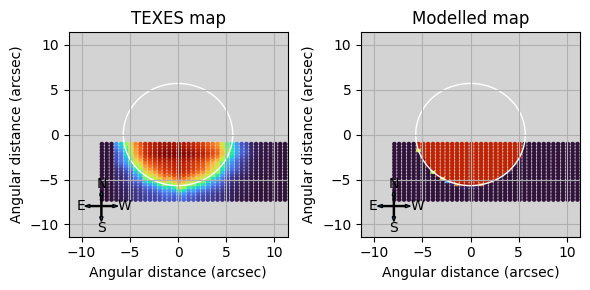

In [7]:
image_calibrate = image_continuum  #Image to use for the calibration

x_ini_off = np.zeros(nimg)   #Offset in the x-axis for each image
y_ini_off = np.zeros(nimg)   #Offset in the y-axis for each image

fitting_method = "uniform"   #Calibrating the geometry based on a uniform disk

max_off = 7.       #Maximum offset with respect to the initial geometry that we search for (default 4 arcsec)
res_off = 0.1      #Resolution of the grid that we use to search for the centre of the disk (default 0.1 arcsec)

printall = False    
calibrate = True
if calibrate is True:

    #Calibrating the geometry of each map
    ix = 0
    for fitsname in fitsnames:

        if ix==0:  #Plotting only the summary of the method for the first map
            makeplot=True
        else:
            if printall:
                makeplot=True
            else:
                makeplot=False
        
        x_ini_off[ix],y_ini_off[ix] = texes.calibrate.calibrate_geometry(geometry,x_vals[:,:,ix],y_vals[:,:,ix],waven_continuum,image_calibrate[:,:,ix],MakePlot=makeplot,convol=False,fitting_method=fitting_method,max_radiance=None,max_off=max_off,res_off=res_off)
        ix += 1

print('x_ini_off = ',x_ini_off)
print('y_ini_off = ',y_ini_off)

x_vals_new = x_vals + x_ini_off
y_vals_new = y_vals + y_ini_off

## 4. Plotting the calibrated measurements

#### PLotting the spatial information

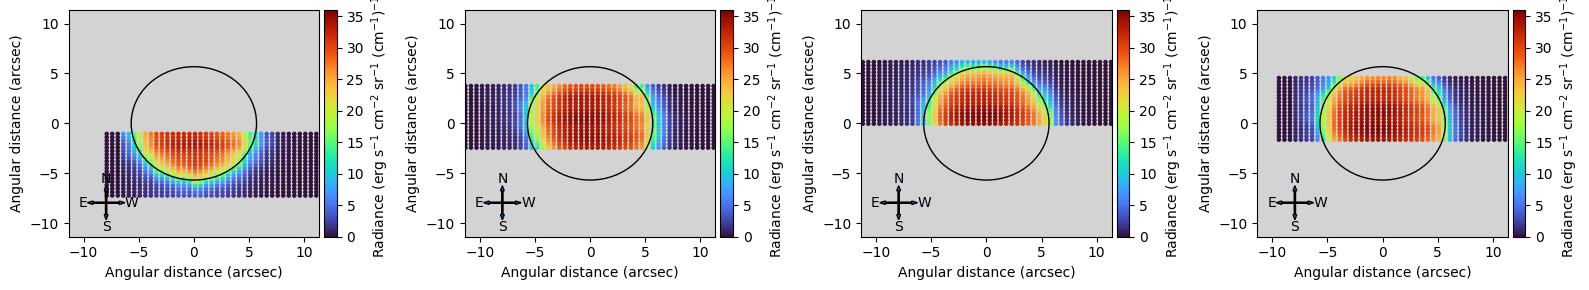

In [8]:
#Plotting images
fig,ax = plt.subplots(1,nimg,figsize=(4*nimg,3))

psize = 5.
vmin = 0. ; vmax = image_continuum.max()
angsize = geometry['angsize']
cmap = 'turbo'

ix = 0
for i in range(nimg):

    if nimg>1:
        axl = ax[i]
    else:
        axl = ax
        
    im = axl.scatter(x_vals_new[:,:,ix],y_vals_new[:,:,ix],c=image_continuum[:,:,ix],s=psize,vmin=vmin,vmax=vmax,cmap=cmap)
    Drawing_uncolored_circle = plt.Circle( (0.0, 0.0), angsize/2. ,fill = False, color='black')
    axl.add_artist( Drawing_uncolored_circle )
    texes.geometry.add_compass(axl)
    axl.set_xlim(-angsize,angsize)
    axl.set_ylim(-angsize,angsize)
    axl.set_facecolor('lightgray')
    axl.set_xlabel('Angular distance (arcsec)')
    axl.set_ylabel('Angular distance (arcsec)')

    # create an axes on the right side of ax. The width of cax will be 5%
    # of ax and the padding between cax and ax will be fixed at 0.05 inch.
    divider = make_axes_locatable(axl)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Radiance (erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)')
        
    ix += 1

plt.tight_layout()

#### Plotting the spectra for a given point

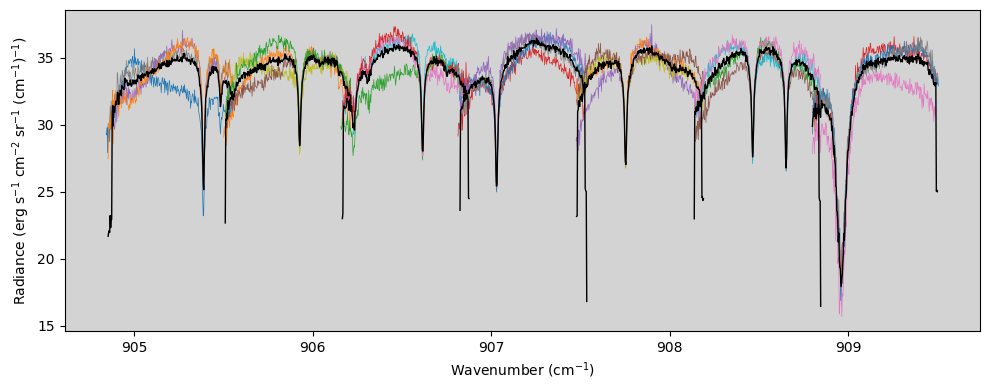

In [10]:
xang = 0. ; yang = 0.   #Angular distance in the x and y axes at which we would like to plot the spectra

fig,ax1 = plt.subplots(1,1,figsize=(10,4))


specave = np.zeros( (nwave,norders) )
for iimg in range(nimg):

    ix = np.argmin( np.abs((x_vals_new[:,0,iimg]-xang)) )  #index of the scan corresponding to the desired angle
    iy = np.argmin( np.abs((y_vals_new[0,:,iimg]-yang)) )  #index of the slit pixel corresponding to the desired angle
        
    for iorder in range(norders):

        iin = np.where(spectra[ix,iy,:,iorder,iimg]>0.0)[0]
        
        ax1.plot(waven[iin,iorder],spectra[ix,iy,iin,iorder,iimg],linewidth=0.5)

        specave[:,iorder] += spectra[ix,iy,:,iorder,iimg]

specave /= nimg

for iorder in range(norders):

    iin = np.where(spectra[ix,iy,:,iorder,iimg]>0.0)[0]
    ax1.plot(waven[iin,iorder],specave[iin,iorder],linewidth=1.,c='black')

ax1.set_ylabel('Radiance (erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)')
ax1.set_xlabel('Wavenumber (cm$^{-1}$)')
ax1.set_facecolor('lightgray')
plt.tight_layout()